# Linformer vs standard attention

One task --- QCD vs $H\to b\bar b$ jet tagging, particles only --- and two attention
implementations:

- **standard:** $\softmax(\mQ\mK^{\top}/\sqrt{d})\,\mV$, attention matrix $L \times L$
- **Linformer:** project the *sequence* axis of $\mK,\mV$ down to $k \ll L$ first,
  attention matrix $L \times k$

We ask two questions and keep them separate:

1. **Does it cost accuracy?** Train both, compare AUC and background rejection.
2. **Does it save anything?** Measure attention memory and step time as a function of $L$.

The second answer turns out to depend entirely on how long your sequences are --- which is the
honest reason this family of methods faded.

In [2]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import math, time, gc
import matplotlib.pyplot as plt

torch.manual_seed(0)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEV, "| torch", torch.__version__)

PART_FEATS = ['part_pt_log','part_e_log','part_logptrel','part_logerel',
              'part_deltaR','part_d0','part_dz']
NPART = 128                       # particles per jet (pad / truncate)

free, total = torch.cuda.mem_get_info()
print(f"free {free/1e9:.1f} GB of {total/1e9:.1f} GB")

device: cuda | torch 2.10.0
free 10.3 GB of 10.5 GB


---
## 1. Load the jets (particles only)

In [4]:
import os, glob

TRAIN_DIR, TREE = "train", "tree"
SIG_PATTERN, BKG_PATTERN = "HBB_*.root", "QCD_*.root"
MAX_PER_CLASS = None
EPS = 1e-8

RAW = ['part_px','part_py','part_energy','part_deta','part_dphi',
       'part_d0val','part_dzval','jet_pt','jet_energy']

def derive(a):
    pt = np.hypot(a['part_px'], a['part_py'])
    return {
        'part_pt_log':   np.log(np.maximum(pt, EPS)),
        'part_e_log':    np.log(np.maximum(a['part_energy'], EPS)),
        'part_logptrel': np.log(np.maximum(pt / a['jet_pt'], EPS)),
        'part_logerel':  np.log(np.maximum(a['part_energy'] / a['jet_energy'], EPS)),
        'part_deltaR':   np.hypot(a['part_deta'], a['part_dphi']),
        'part_d0':       np.tanh(a['part_d0val']),
        'part_dz':       np.tanh(a['part_dzval']),
    }

def load_real():
    import uproot, awkward as ak
    def _pad(x, n):
        return ak.to_numpy(ak.fill_none(ak.pad_none(x, n, clip=True), 0.0)).astype(np.float32)
    def one(pattern, label):
        files = sorted(glob.glob(os.path.join(TRAIN_DIR, pattern)))
        if not files: raise FileNotFoundError(f"{TRAIN_DIR}/{pattern}")
        a = uproot.concatenate([f"{f}:{TREE}" for f in files], RAW, library="ak")
        if MAX_PER_CLASS: a = a[:MAX_PER_CLASS]
        P = np.stack([_pad(derive(a)[b], NPART) for b in PART_FEATS], -1)
        m = _pad(ak.ones_like(a['part_energy']), NPART)
        print(f"  {pattern:12s} {len(files)} files -> {len(P):6,} jets")
        return P, m, np.full(len(P), label, np.float32)
    s = one(SIG_PATTERN, 1.0); b = one(BKG_PATTERN, 0.0)
    return [np.concatenate([u, v]) for u, v in zip(b, s)]



X, MASK, Y = load_real(); print("loaded ROOT files")

perm = np.random.default_rng(0).permutation(len(Y))
X, MASK, Y = X[perm], MASK[perm], Y[perm]
ntr = int(0.8*len(Y)); tr, te = slice(0, ntr), slice(ntr, len(Y))

flat = X[:ntr][MASK[:ntr] > 0]
mu, sd = flat.mean(0), flat.std(0) + 1e-6
X = ((X - mu)/sd * MASK[..., None]).astype(np.float32)

print(f"\n{len(Y):,} jets | signal fraction {Y.mean():.3f} | "
      f"mean particles/jet {MASK.sum(1).mean():.1f}")

def batches(sl, bs, shuffle=True):
    n = len(Y[sl]); order = np.random.permutation(n) if shuffle else np.arange(n)
    for a in range(0, n, bs):
        j = order[a:a+bs]
        yield tuple(torch.from_numpy(v[sl][j]).to(DEV) for v in (X, MASK, Y))

  HBB_*.root   2 files -> 200,000 jets
  QCD_*.root   2 files -> 200,000 jets
loaded ROOT files

400,000 jets | signal fraction 0.500 | mean particles/jet 38.7


---
## 2. Two attentions, one interface

The only difference is what happens to $\mK$ and $\mV$ before the scores are computed.

`E_K, E_V` $\in \R^{k\times L}$ are **learned** matrices that mix the $L$ keys (values) into $k$
summaries. Note they act on the *sequence* axis --- which is why $L$ has to be fixed at
construction time.

One detail that matters: padded positions are zeroed **before** projecting, otherwise padding
leaks into every summary.

In [5]:
class StandardAttention(nn.Module):
    kind = "standard"
    def __init__(self, d, nheads, L=None, k=None):
        super().__init__()
        self.h, self.dh = nheads, d//nheads
        self.qkv = nn.Linear(d, 3*d, bias=False); self.o = nn.Linear(d, d, bias=False)
        self.score_numel = 0
    def forward(self, x, mask):
        B, L, D = x.shape; H, dh = self.h, self.dh
        q, k, v = [t.view(B,L,H,dh).transpose(1,2) for t in self.qkv(x).chunk(3, -1)]
        s = (q @ k.transpose(-2,-1)) / math.sqrt(dh)          # B,H,L,L
        self.score_numel = s.numel()
        s = s.masked_fill(mask[:,None,None,:] == 0, float('-inf'))
        a = torch.nan_to_num(s.softmax(-1))
        return self.o((a @ v).transpose(1,2).reshape(B,L,D))

class LinformerAttention(nn.Module):
    kind = "linformer"
    def __init__(self, d, nheads, L, k):
        super().__init__()
        self.h, self.dh, self.k = nheads, d//nheads, k
        self.qkv = nn.Linear(d, 3*d, bias=False); self.o = nn.Linear(d, d, bias=False)
        self.E_K = nn.Parameter(torch.randn(k, L)/math.sqrt(L))
        self.E_V = nn.Parameter(torch.randn(k, L)/math.sqrt(L))
        self.score_numel = 0
    def forward(self, x, mask):
        B, L, D = x.shape; H, dh = self.h, self.dh
        q, k, v = [t.view(B,L,H,dh).transpose(1,2) for t in self.qkv(x).chunk(3, -1)]
        mk = mask[:,None,:,None]
        k, v = k*mk, v*mk                                     # kill padding before mixing
        k = torch.einsum('kl,bhld->bhkd', self.E_K, k)        # B,H,k,dh
        v = torch.einsum('kl,bhld->bhkd', self.E_V, v)
        s = (q @ k.transpose(-2,-1)) / math.sqrt(dh)          # B,H,L,k   <- the whole point
        self.score_numel = s.numel()
        a = s.softmax(-1)                                     # no mask: summaries are all valid
        return self.o((a @ v).transpose(1,2).reshape(B,L,D))

class Block(nn.Module):
    def __init__(self, Attn, d, nheads, ff, L, k):
        super().__init__()
        self.n1, self.n2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.att = Attn(d, nheads, L, k)
        self.ff  = nn.Sequential(nn.Linear(d, ff), nn.GELU(), nn.Linear(ff, d))
    def forward(self, x, m):
        x = x + self.att(self.n1(x), m)
        return x + self.ff(self.n2(x))

def feature_mlp(n_in, d):
    return nn.Sequential(nn.Linear(n_in, d), nn.LayerNorm(d), nn.GELU(),
                         nn.Linear(d, d),    nn.LayerNorm(d), nn.GELU(),
                         nn.Linear(d, d))

class Tagger(nn.Module):
    def __init__(self, nfeat, Attn, L=NPART, k=32, d=64, nheads=4, nlayers=3, ff=128):
        super().__init__()
        self.emb = feature_mlp(nfeat, d)
        self.blocks = nn.ModuleList([Block(Attn, d, nheads, ff, L, k) for _ in range(nlayers)])
        self.nf, self.head = nn.LayerNorm(d), nn.Linear(d, 1)
    def forward(self, x, m):
        h = self.emb(x)
        for b in self.blocks: h = b(h, m)
        h = self.nf(h)
        return self.head((h*m[...,None]).sum(1) / m.sum(1, keepdim=True).clamp(min=1)).squeeze(-1)
    def score_entries(self):
        return sum(b.att.score_numel for b in self.blocks)

for Attn, kw in [(StandardAttention, {}), (LinformerAttention, dict(k=32))]:
    n = sum(p.numel() for p in Tagger(len(PART_FEATS), Attn, **kw).parameters())
    print(f"{Attn.kind:11s} {n:,} parameters")
    
print("Linformer trades parameters for FLOPs!")

standard    108,929 parameters
linformer   133,505 parameters
Linformer trades parameters for FLOPs!


---
## 3. Question 1: does it cost accuracy?


model              params     AUC   rej@50%   rej@30%  train s
standard          108,929  0.9858     257.5     647.9        6
linformer k=4     112,001  0.9819     244.9     647.9        5
linformer k=32    133,505  0.9837     242.0     669.5        5
linformer k=64    158,081  0.9840     243.4     892.6        5

background jets surviving the 30% working point: {'standard': 62, 'linformer k=4': 62, 'linformer k=32': 60, 'linformer k=64': 45}


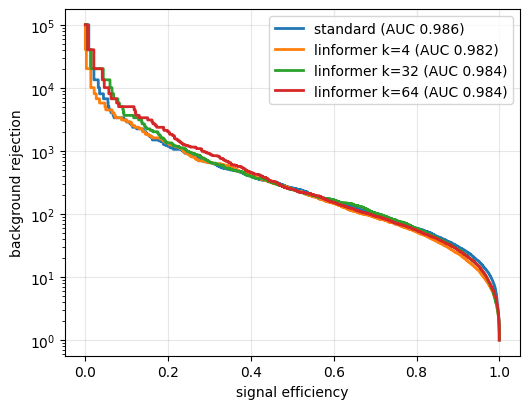

In [7]:
def metrics(p, y, effs=(0.5, 0.3)):
    o = np.argsort(-p); s = y[o]
    tpr = np.cumsum(s)/s.sum(); fpr = np.cumsum(1-s)/(1-s).sum()
    auc = float(np.trapezoid(tpr, fpr)) if hasattr(np,'trapezoid') else float(np.trapz(tpr, fpr))
    sig, bkg = p[y > .5], p[y < .5]
    rej, nsurv = {}, {}
    for e in effs:
        thr = np.quantile(sig, 1-e)
        nsurv[e] = int((bkg > thr).sum())
        rej[e] = 1.0/max(nsurv[e]/len(bkg), 1/len(bkg))
    return auc, rej, nsurv, (fpr, tpr)

def train_eval(Attn, k=32, steps=500, bs=64, lr=2e-3, seed=0):
    torch.manual_seed(seed)
    net = Tagger(len(PART_FEATS), Attn, L=NPART, k=k).to(DEV)
    opt = torch.optim.AdamW(net.parameters(), lr=lr, betas=(0.9,0.95), weight_decay=0.01)
    sch = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min((s+1)/40, 1.0))
    if DEV == "cuda": torch.cuda.reset_peak_memory_stats()
    step, t0 = 0, time.time(); net.train()
    while step < steps:
        for xb, mb, yb in batches(tr, bs):
            loss = F.binary_cross_entropy_with_logits(net(xb, mb), yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0); opt.step(); sch.step()
            step += 1
            if step >= steps: break
    secs = time.time()-t0
    net.eval(); P, YS = [], []
    with torch.no_grad():
        for xb, mb, yb in batches(te, 256, shuffle=False):
            P.append(torch.sigmoid(net(xb, mb)).cpu().numpy()); YS.append(yb.cpu().numpy())
    P, YS = np.concatenate(P), np.concatenate(YS)
    auc, rej, nsurv, roc = metrics(P, YS)
    r = dict(name=Attn.kind if Attn is StandardAttention else f"linformer k={k}",
             auc=auc, rej=rej, nsurv=nsurv, roc=roc, secs=secs,
             nparam=sum(p.numel() for p in net.parameters()),
             peak_MB=(torch.cuda.max_memory_allocated()/1e6 if DEV=="cuda" else float('nan')))
    del net; gc.collect()
    if DEV == "cuda": torch.cuda.empty_cache()
    return r

results = [train_eval(StandardAttention)]
for k in (4, 32, 64):
    results.append(train_eval(LinformerAttention, k=k))

print(f"\n{'model':16s}{'params':>9}{'AUC':>8}{'rej@50%':>10}{'rej@30%':>10}{'train s':>9}")
for r in results:
    print(f"{r['name']:16s}{r['nparam']:>9,}{r['auc']:8.4f}"
          f"{r['rej'][0.5]:10.1f}{r['rej'][0.3]:10.1f}{r['secs']:9.0f}")
print("\nbackground jets surviving the 30% working point:",
      {r['name']: r['nsurv'][0.3] for r in results})

plt.figure(figsize=(5.4,4.2))
for r in results:
    fpr, tpr = r["roc"]
    plt.plot(tpr, 1/np.clip(fpr,1e-5,None), lw=2, label=f"{r['name']} (AUC {r['auc']:.3f})")
plt.yscale("log"); plt.xlabel("signal efficiency"); plt.ylabel("background rejection")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### What to expect

At $L = 128$ the projection has very little to gain and something to lose: $k = 64$ should be
close to standard, $k = 4$ noticeably worse. Watch the **surviving background counts** too --- if
only a handful of jets pass the 30\% working point, that rejection number is Poisson noise, not a
measurement.

---
## 4. Question 2: does it save anything?

Accuracy is only half the question. Now measure the actual cost as a function of sequence length,
with a synthetic batch (no training, just a forward and backward pass).

L=  128  standard     7.0 ms /      6.3 MB    linformer     7.9 ms /      3.1 MB    (  2.0x less memory)
L=  256  standard     7.3 ms /     25.2 MB    linformer     7.8 ms /      6.3 MB    (  4.0x less memory)
L=  512  standard    17.8 ms /    100.7 MB    linformer     7.9 ms /     12.6 MB    (  8.0x less memory)
L= 1024  standard    64.3 ms /    402.7 MB    linformer     9.8 ms /     25.2 MB    ( 16.0x less memory)


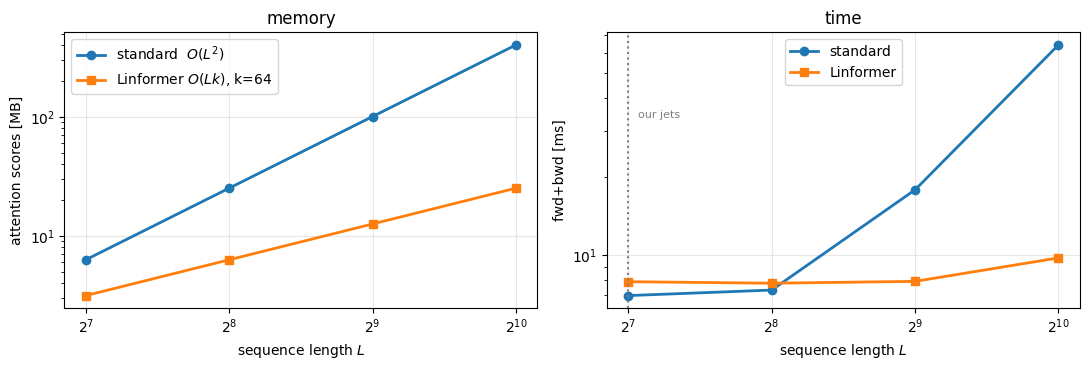

In [8]:
def bench(Attn, L, k=64, B=8, d=64, nheads=4, nlayers=3, reps=3):
    net = Tagger(len(PART_FEATS), Attn, L=L, k=k, d=d, nheads=nheads, nlayers=nlayers).to(DEV)
    x = torch.randn(B, L, len(PART_FEATS), device=DEV)
    m = torch.ones(B, L, device=DEV); y = torch.rand(B, device=DEV).round()
    if DEV == "cuda": torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
    for _ in range(2):                                       # warm up
        F.binary_cross_entropy_with_logits(net(x, m), y).backward()
    net.zero_grad(set_to_none=True)
    if DEV == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(reps):
        F.binary_cross_entropy_with_logits(net(x, m), y).backward()
        net.zero_grad(set_to_none=True)
    if DEV == "cuda": torch.cuda.synchronize()
    ms = (time.time()-t0)/reps*1e3
    entries = net.score_entries()
    peak = torch.cuda.max_memory_allocated()/1e6 if DEV == "cuda" else float('nan')
    del net, x, m, y; gc.collect()
    if DEV == "cuda": torch.cuda.empty_cache()
    return dict(L=L, ms=ms, entries=entries, score_MB=entries*4/1e6, peak_MB=peak)

LENGTHS = [128, 256, 512, 1024]          # add 2048, 4096 on a GPU
K = 64
rows = []
for L in LENGTHS:
    a = bench(StandardAttention, L)
    b = bench(LinformerAttention, L, k=K)
    rows.append((L, a, b))
    print(f"L={L:5d}  standard {a['ms']:7.1f} ms / {a['score_MB']:8.1f} MB    "
          f"linformer {b['ms']:7.1f} ms / {b['score_MB']:8.1f} MB    "
          f"({a['score_MB']/max(b['score_MB'],1e-9):5.1f}x less memory)", flush=True)

fig, ax = plt.subplots(1, 2, figsize=(11,3.8))
Ls = [r[0] for r in rows]
ax[0].plot(Ls, [r[1]['score_MB'] for r in rows], 'o-', lw=2, label='standard  $O(L^2)$')
ax[0].plot(Ls, [r[2]['score_MB'] for r in rows], 's-', lw=2, label=f'Linformer $O(Lk)$, k={K}')
ax[0].set_xscale('log',base=2); ax[0].set_yscale('log')
ax[0].set_xlabel('sequence length $L$'); ax[0].set_ylabel('attention scores [MB]')
ax[0].set_title('memory'); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(Ls, [r[1]['ms'] for r in rows], 'o-', lw=2, label='standard')
ax[1].plot(Ls, [r[2]['ms'] for r in rows], 's-', lw=2, label='Linformer')
ax[1].axvline(NPART, ls=':', c='gray'); ax[1].text(NPART*1.05, ax[1].get_ylim()[1]*0.5,
                                                   'our jets', fontsize=8, color='gray')
ax[1].set_xscale('log',base=2); ax[1].set_yscale('log')
ax[1].set_xlabel('sequence length $L$'); ax[1].set_ylabel('fwd+bwd [ms]')
ax[1].set_title('time'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## Verdict


- **On accuracy**, Linformer with a generous $k$ is roughly competitive here, and gets worse as
  $k$ shrinks. It is an approximation, and it behaves like one.
- **On resources**, the saving is real but only bites once $L^2$ dominates.

So the method solves a problem our jets do not have. And for the sequences where it *would* help,
FlashAttention gets the same memory relief **exactly**, with no approximation and no accuracy
question to answer.

Two further limitations worth noting, both structural:

- $E_K, E_V \in \R^{k\times L}$ **fix the sequence length at construction**. A trained Linformer
  cannot be run on longer inputs --- try changing `NPART` and reloading a checkpoint.
- They cost real parameters, $2kL$ per layer, whereas a sliding window or FlashAttention cost
  none at all.

That is the short version of why this line of work faded: it competed on speed against a method
that was getting faster *and* stayed exact.